## Turma: DADOS - 2025.2

## Materia: RNA e Deep Learning

### Nome: Wagner Ferreira Porto de Vasconcelos


# Dataset utilizado - Old car price prediction

Os dados utlizados estão neste dataset -
  https://www.kaggle.com/api/v1/datasets/download/milanvaddoriya/old-car-price-prediction


## Importação das bibliotecas


In [2]:
from os.path import exists

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carregar DataSet

In [3]:

# !/bin/bash
# !curl -L -o /content/old-car-price-prediction.zip\
#   https://www.kaggle.com/api/v1/datasets/download/milanvaddoriya/old-car-price-prediction

In [4]:
# !unzip /content/old-car-price-prediction.zip

In [5]:
df = pd.read_csv("/content/car_price.csv")

In [6]:
df.head(5)

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           5512 non-null   int64 
 1   car_name             5512 non-null   object
 2   car_prices_in_rupee  5512 non-null   object
 3   kms_driven           5512 non-null   object
 4   fuel_type            5512 non-null   object
 5   transmission         5512 non-null   object
 6   ownership            5512 non-null   object
 7   manufacture          5512 non-null   int64 
 8   engine               5512 non-null   object
 9   Seats                5512 non-null   object
dtypes: int64(2), object(8)
memory usage: 430.8+ KB


In [14]:
df.describe()

,Unnamed: 0,manufacture,preco,km,motor,lugares,combustivel,cambio,dono
count,5382.000000,5382.000000,5382.000000,5382.000000,5382.000000,5382.000000,5382.000000,5382.000000,5382.000000
mean,2753.267559,2015.642326,11.844896,62939.723523,1534.526384,5.251394,0.500372,0.286696,1.407098
std,1598.084271,3.712750,19.838179,41859.606756,581.849325,0.720175,0.579251,0.452261,0.682302
min,0.000000,1995.000000,1.000000,250.000000,0.000000,2.000000,0.000000,0.000000,1.000000
25%,1366.250000,2013.000000,3.250000,32982.000000,1197.000000,5.000000,0.000000,0.000000,1.000000
50%,2752.500000,2016.000000,5.605000,58476.500000,1396.000000,5.000000,0.000000,0.000000,1.000000
75%,4142.750000,2018.000000,10.500000,83950.000000,1950.000000,5.000000,1.000000,1.000000,2.000000
max,5511.000000,2022.000000,192.000000,560000.000000,5950.000000,8.000000,4.000000,1.000000,5.000000


In [8]:
df.columns

Index(['Unnamed: 0', 'car_name', 'car_prices_in_rupee', 'kms_driven',
       'fuel_type', 'transmission', 'ownership', 'manufacture', 'engine',
       'Seats'],
      dtype='object')

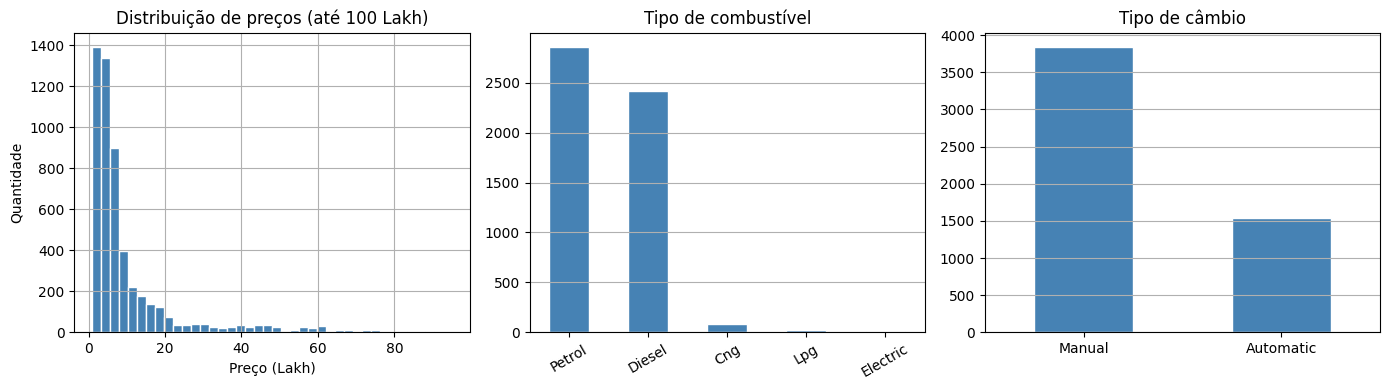

Preço médio  : 11.84 Lakh
Preço mínimo : 1.00 Lakh
Preço máximo : 192.00 Lakh


In [15]:
def converter_preco_viz(valor):
    valor = str(valor).strip()
    if 'Crore' in valor:
        return float(valor.replace('Crore', '').strip()) * 100
    elif 'Lakh' in valor:
        return float(valor.replace('Lakh', '').strip())
    return None

preco_viz = df['car_prices_in_rupee'].apply(converter_preco_viz).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))


axes[0].hist(preco_viz[preco_viz < 100], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de preços (até 100 Lakh)')
axes[0].set_xlabel('Preço (Lakh)')
axes[0].set_ylabel('Quantidade')
axes[0].grid(True)


df['fuel_type'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Tipo de combustível')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, axis='y')


df['transmission'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Tipo de câmbio')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f'Preço médio  : {preco_viz.mean():.2f} Lakh')
print(f'Preço mínimo : {preco_viz.min():.2f} Lakh')
print(f'Preço máximo : {preco_viz.max():.2f} Lakh')

## Preparação dos dados

In [9]:
def preparar_dados(df):
    df = df.copy()

    def converter_preco(valor):
        valor = str(valor).strip()
        if 'Crore' in valor:
            return float(valor.replace('Crore', '').strip()) * 100
        elif 'Lakh' in valor:
            return float(valor.replace('Lakh', '').strip())
        return None

    df['preco']  = df['car_prices_in_rupee'].apply(converter_preco)
    df['km']     = df['kms_driven'].str.replace(',','').str.replace(' kms','').str.strip().astype(float)
    df['motor']  = df['engine'].str.replace(' cc','').str.strip().astype(float)
    df['lugares'] = df['Seats'].str.replace(' Seats','').str.strip().astype(float)

    # Variáveis categóricas — mapeamento manual
    mapa_combustivel = {'Petrol':0, 'Diesel':1, 'Cng':2, 'Lpg':3, 'Electric':4}
    mapa_cambio      = {'Manual':0, 'Automatic':1}
    mapa_dono        = {'UnRegistered Car':0, '1st Owner':1,
                        '2nd Owner':2, '3rd Owner':3,
                        '4th Owner':4, '5th Owner':5}

    df['combustivel'] = df['fuel_type'].map(mapa_combustivel)
    df['cambio']      = df['transmission'].map(mapa_cambio)
    df['dono']        = df['ownership'].map(mapa_dono)

    colunas = ['preco','km','motor','lugares','combustivel','cambio','dono','manufacture']
    df = df.dropna(subset=colunas)

    print(f'Registros após limpeza: {len(df)}')
    return df

df = preparar_dados(df)

Registros após limpeza: 5382


## Conversão para tensores

In [10]:
def construir_tensores(df, proporcao_treino=0.8):
    cols_entrada = ['km', 'manufacture', 'motor', 'lugares',
                    'combustivel', 'cambio', 'dono']

    X = df[cols_entrada].values.astype(float)
    y = df['preco'].values.reshape(-1, 1).astype(float)

    # Normalização
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    y_med, y_dp = y.mean(), y.std() + 1e-8
    y = (y - y_med) / y_dp

    corte = int(len(X) * proporcao_treino)
    X_tr  = torch.FloatTensor(X[:corte])
    X_te  = torch.FloatTensor(X[corte:])
    y_tr  = torch.FloatTensor(y[:corte])
    y_te  = torch.FloatTensor(y[corte:])

    print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')
    return X_tr, X_te, y_tr, y_te, y_med, y_dp

X_train, X_test, y_train, y_test, y_med, y_dp = construir_tensores(df)

Treino: torch.Size([4305, 7]) | Teste: torch.Size([1077, 7])


## Treinamento

In [11]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(7, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print(Net())

Net(
  (fc1): Linear(in_features=7, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [12]:
def executar_epoca(modelo, X, y, otimizador, criterio, treinar=True):
    if treinar:
        modelo.train()
        otimizador.zero_grad()
        saida = modelo(X)
        perda = criterio(saida, y)
        perda.backward()
        otimizador.step()
    else:
        modelo.eval()
        with torch.no_grad():
            saida = modelo(X)
            perda = criterio(saida, y)
    return perda.item()


def treinar_modelo(modelo, X_tr, y_tr, X_te, y_te, epocas=50):
    otimizador = optim.Adadelta(modelo.parameters(), lr=1.0)
    criterio   = nn.MSELoss()
    scheduler  = StepLR(otimizador, step_size=10, gamma=0.7)

    historico = {'treino': [], 'teste': []}

    for epoca in range(1, epocas + 1):
        perda_tr = executar_epoca(modelo, X_tr, y_tr, otimizador, criterio, treinar=True)
        perda_te = executar_epoca(modelo, X_te, y_te, otimizador, criterio, treinar=False)
        scheduler.step()

        historico['treino'].append(perda_tr)
        historico['teste'].append(perda_te)

        if epoca % 10 == 0:
            print(f'Época {epoca}/{epocas} | Treino: {perda_tr:.4f} | Teste: {perda_te:.4f}')

    print('Treinamento concluído.')
    return historico

modelo = Net()
historico = treinar_modelo(modelo, X_train, y_train, X_test, y_test)

Época 10/50 | Treino: 0.6924 | Teste: 0.5824
Época 20/50 | Treino: 0.6185 | Teste: 0.5312
Época 30/50 | Treino: 0.5959 | Teste: 0.5207
Época 40/50 | Treino: 0.5866 | Teste: 0.5185
Época 50/50 | Treino: 0.5820 | Teste: 0.5182
Treinamento concluído.


## Avaliação do Modelo

MAE  : 5.75 Lakh
RMSE : 14.28 Lakh
R²   : 0.4439


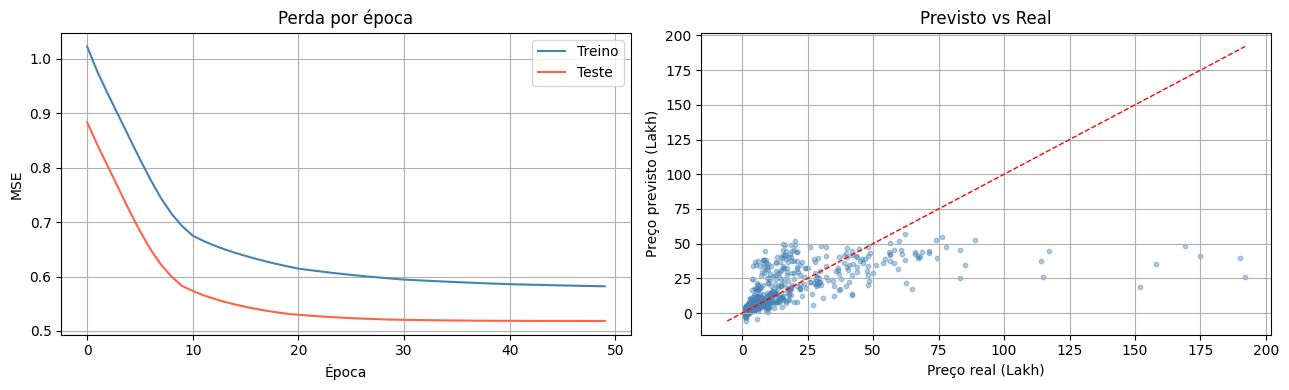

In [13]:
def avaliar_modelo(modelo, X_te, y_te, y_med, y_dp, historico):
    modelo.eval()
    with torch.no_grad():
        previsto = modelo(X_te).numpy()

    # Desfaz a normalização para voltar à escala original (Lakh)
    previsto_real = previsto * y_dp + y_med
    real          = y_te.numpy() * y_dp + y_med

    mae  = abs(previsto_real - real).mean()
    rmse = ((previsto_real - real) ** 2).mean() ** 0.5
    r2   = 1 - ((real - previsto_real)**2).sum() / ((real - real.mean())**2).sum()

    print(f'MAE  : {mae:.2f} Lakh')
    print(f'RMSE : {rmse:.2f} Lakh')
    print(f'R²   : {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(historico['treino'], label='Treino', color='steelblue')
    axes[0].plot(historico['teste'],  label='Teste',  color='tomato')
    axes[0].set_title('Perda por época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].scatter(real, previsto_real, alpha=0.4, s=10, color='steelblue')
    lim = [min(real.min(), previsto_real.min()), max(real.max(), previsto_real.max())]
    axes[1].plot(lim, lim, 'r--', linewidth=1)
    axes[1].set_title('Previsto vs Real')
    axes[1].set_xlabel('Preço real (Lakh)')
    axes[1].set_ylabel('Preço previsto (Lakh)')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

avaliar_modelo(modelo, X_test, y_test, y_med, y_dp, historico)

# Conclusão

A maior dificuldade do trabalho foi fazer as curvas de treino e teste convergirem juntas. Durante o processo, o gráfico mostrava as duas linhas separadas, a de teste ficava abaixo da de treino o que indicava que o modelo estava se comportando de forma diferente em cada conjunto. Foram testadas algumas configurações, como alterar o tamanho da rede e o otimizador, até chegar em uma versão estável onde as curvas desciam de forma mais consistente. No geral, não foram necessários muitos ajustes a arquitetura base funcionou bem e o processo de treinamento correu sem grandes problemas.

No geral o modelo funcionou, mas o trabalho deixou claro que a qualidade e a distribuição dos dados fazem muita diferença no resultado ter poucos exemplos de carros caros foi o principal limitador do desempenho final.